In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('BankChurners.csv')
print(f"Original shape: {df.shape}")
print("Original column count:", len(df.columns))

Original shape: (10127, 23)
Original column count: 23


In [2]:
# Identify random ID and Kaggle pre-computed classifier leakage columns
leakage_cols = [c for c in df.columns if c.startswith('Naive_Bayes_Classifier')]
drop_cols = ['CLIENTNUM'] + leakage_cols

# Drop the columns
df_cleaned = df.drop(columns=drop_cols)

print("Columns removed:", drop_cols)
print(f"New shape: {df_cleaned.shape}")

Columns removed: ['CLIENTNUM', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']
New shape: (10127, 20)


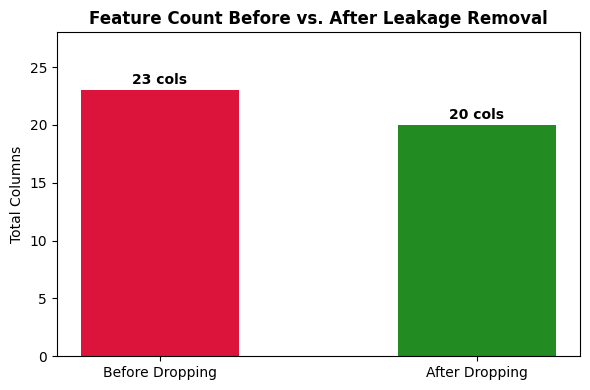

Deliverable saved to: results/eda_visualizations/IT25102085_leakage_removal.png


In [3]:
import os
import matplotlib.pyplot as plt

# Create output folder
os.makedirs('results/eda_visualizations', exist_ok=True)

# Visualize columns before vs after
plt.figure(figsize=(6, 4))
labels = ['Before Dropping', 'After Dropping']
counts = [df.shape[1], df_cleaned.shape[1]]

bars = plt.bar(labels, counts, color=['crimson', 'forestgreen'], width=0.5)
plt.title('Feature Count Before vs. After Leakage Removal', fontweight='bold')
plt.ylabel('Total Columns')
plt.ylim(0, max(counts) + 5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval} cols', ha='center', fontweight='bold')

plt.tight_layout()
plot_path = 'results/eda_visualizations/IT25102085_leakage_removal.png'
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"Deliverable saved to: {plot_path}")